# EDA - Store Sales Time Series Forecasting

Cilj: razumjeti podatke prije feature engineeringa i modeliranja.

Fajlovi:
- `train.csv` - dnevna prodaja po prodavnici i kategoriji (2013-2017)
- `stores.csv` - metadata prodavnica
- `transactions.csv` - broj transakcija po danu
- `oil.csv` - dnevna cijena nafte
- `holidays_events.csv` - praznici i eventi

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)

DATA = '../data/raw/'
EARTHQUAKE_DATE = pd.Timestamp('2016-04-16')

## 1. Ucitavanje podataka

In [10]:
train        = pd.read_csv(DATA + 'train.csv', parse_dates=['date'])
stores       = pd.read_csv(DATA + 'stores.csv')
transactions = pd.read_csv(DATA + 'transactions.csv', parse_dates=['date'])
oil          = pd.read_csv(DATA + 'oil.csv', parse_dates=['date'])
holidays     = pd.read_csv(DATA + 'holidays_events.csv', parse_dates=['date'])

print(f'train:        {train.shape}')
print(f'stores:       {stores.shape}')
print(f'transactions: {transactions.shape}')
print(f'oil:          {oil.shape}')
print(f'holidays:     {holidays.shape}')

train:        (3000888, 6)
stores:       (54, 5)
transactions: (83488, 3)
oil:          (1218, 2)
holidays:     (350, 6)


## 2. train.csv

In [11]:
train.head(10)

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


In [12]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB


In [13]:
print('Missing values:')
print(train.isnull().sum())
print(f'\nPeriod: {train.date.min().date()} do {train.date.max().date()}')
print(f'Prodavnice: {train.store_nbr.nunique()}')
print(f'Kategorije: {train.family.nunique()}')
print(f'Redova sa sales=0: {(train.sales == 0).sum():,} ({(train.sales == 0).mean():.1%})')

Missing values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Period: 2013-01-01 do 2017-08-15
Prodavnice: 54
Kategorije: 33
Redova sa sales=0: 939,130 (31.3%)


In [14]:
train.sales.describe()

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

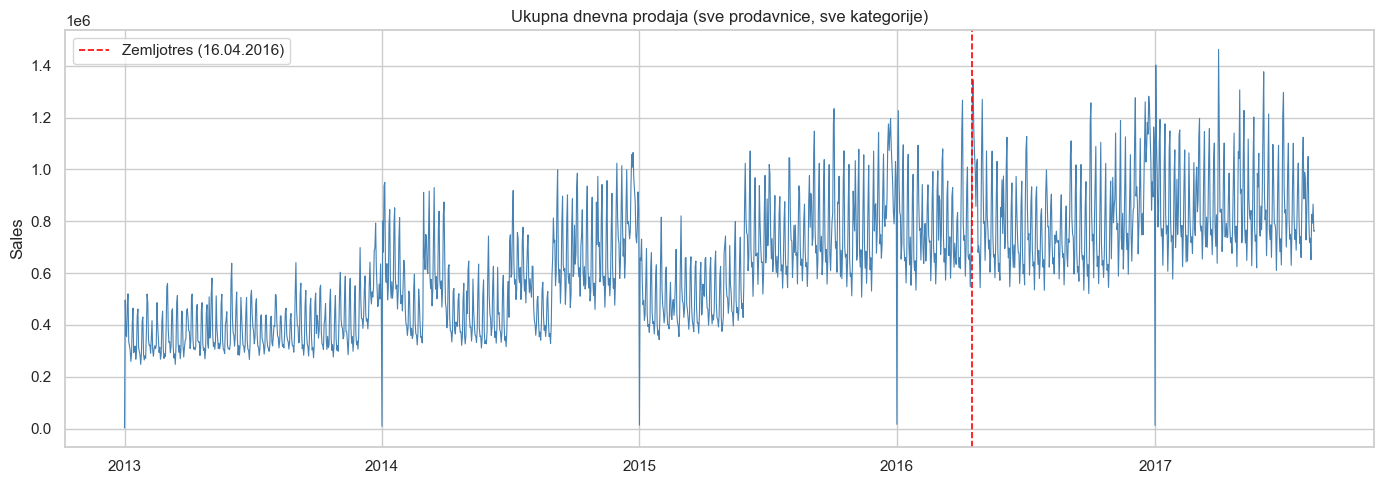

In [15]:
# Ukupna dnevna prodaja kroz cijeli period
daily = train.groupby('date')['sales'].sum()

fig, ax = plt.subplots()
ax.plot(daily.index, daily.values, linewidth=0.8, color='steelblue')
ax.axvline(EARTHQUAKE_DATE, color='red', linestyle='--', linewidth=1.2, label='Zemljotres (16.04.2016)')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Ukupna dnevna prodaja (sve prodavnice, sve kategorije)')
ax.set_ylabel('Sales')
ax.legend()
plt.tight_layout()
plt.show()

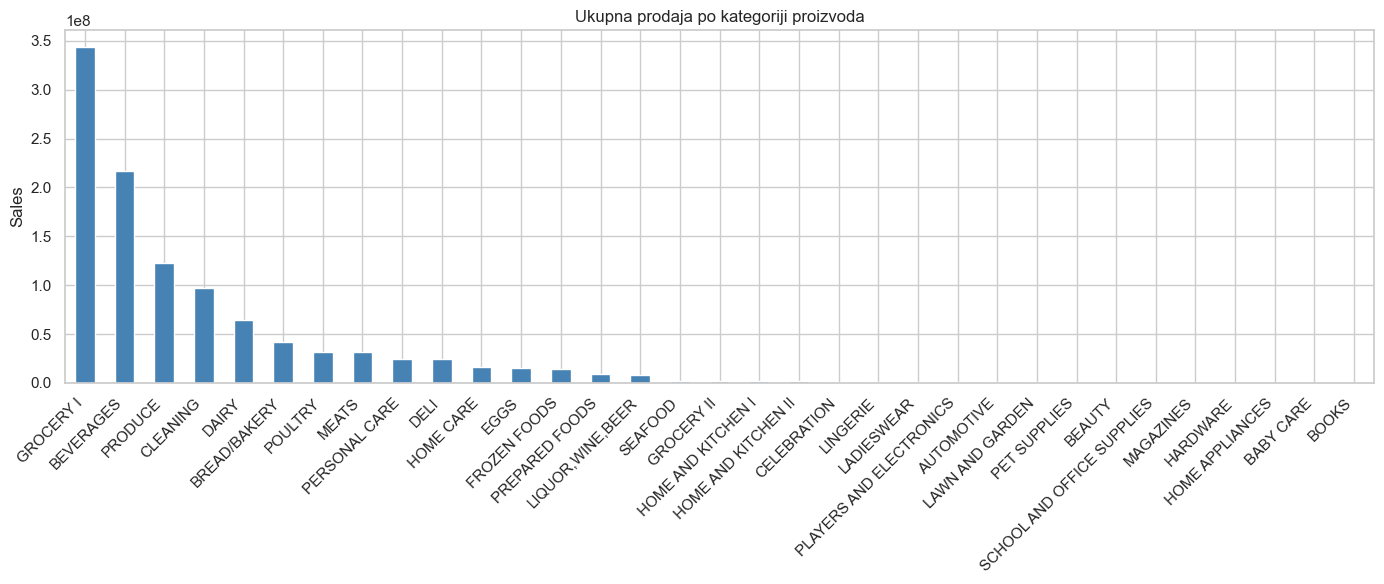

In [16]:
# Prodaja po kategoriji
by_family = train.groupby('family')['sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
by_family.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Ukupna prodaja po kategoriji proizvoda')
ax.set_xlabel('')
ax.set_ylabel('Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

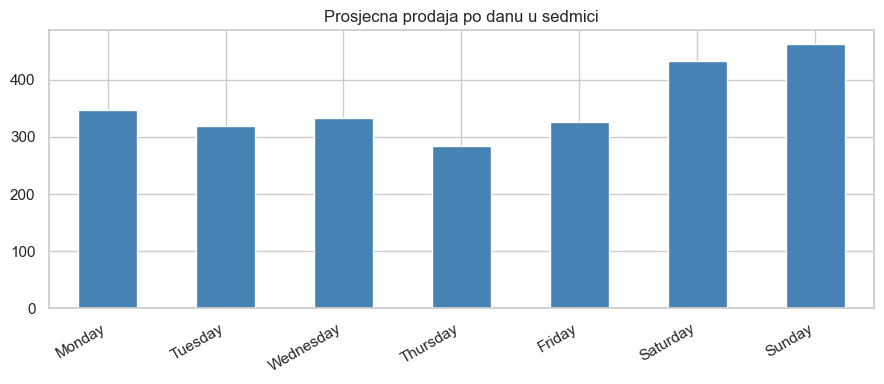

In [17]:
# Sezonalnost: prodaja po danu u sedmici
train['dayofweek'] = train.date.dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
by_dow = train.groupby('dayofweek')['sales'].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 4))
by_dow.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Prosjecna prodaja po danu u sedmici')
ax.set_xlabel('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

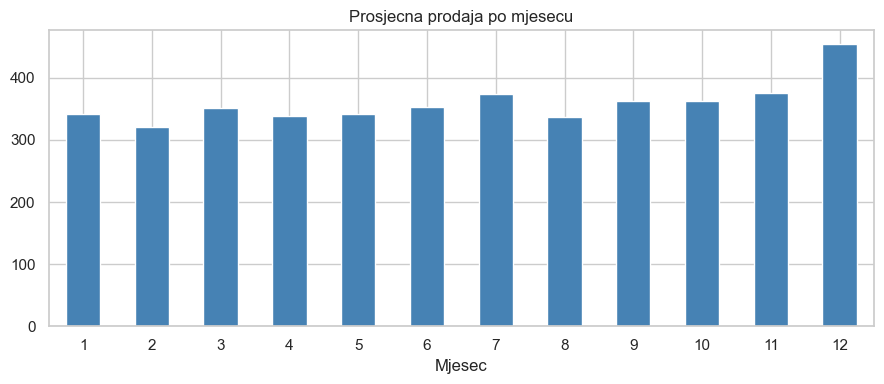

In [18]:
# Sezonalnost: prodaja po mjesecu
train['month'] = train.date.dt.month
by_month = train.groupby('month')['sales'].mean()

fig, ax = plt.subplots(figsize=(9, 4))
by_month.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Prosjecna prodaja po mjesecu')
ax.set_xlabel('Mjesec')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
# Efekat promocija
print('Prosjecna prodaja - nula stavki na promociji:', round(train[train.onpromotion == 0]['sales'].mean(), 2))
print('Prosjecna prodaja - barem jedna stavka na promociji:', round(train[train.onpromotion > 0]['sales'].mean(), 2))

Prosjecna prodaja - nula stavki na promociji: 158.25
Prosjecna prodaja - barem jedna stavka na promociji: 1137.69


## 3. stores.csv

In [20]:
stores.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


In [21]:
print('Tipovi prodavnica:', stores['type'].value_counts().to_dict())
print('Gradovi:', stores['city'].nunique())
print('Clusteri:', stores['cluster'].nunique())
stores.describe()

Tipovi prodavnica: {'D': 18, 'C': 15, 'A': 9, 'B': 8, 'E': 4}
Gradovi: 22
Clusteri: 17


,store_nbr,cluster
count,54.000000,54.000000
mean,27.500000,8.481481
std,15.732133,4.693395
min,1.000000,1.000000
25%,14.250000,4.000000
50%,27.500000,8.500000
75%,40.750000,13.000000
max,54.000000,17.000000


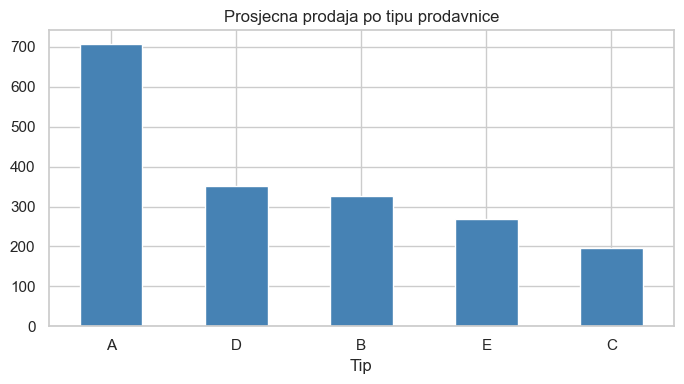

In [22]:
# Prodaja po tipu prodavnice
train_stores = train.merge(stores, on='store_nbr')
by_type = train_stores.groupby('type')['sales'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
by_type.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Prosjecna prodaja po tipu prodavnice')
ax.set_xlabel('Tip')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. transactions.csv

In [23]:
transactions.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


Korelacija (sales vs transactions): 0.677


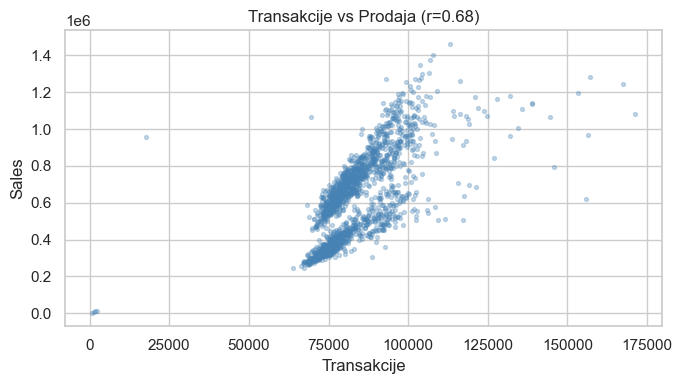

In [24]:
# Korelacija transakcija i prodaje
daily_sales = train.groupby('date')['sales'].sum().reset_index()
daily_trans = transactions.groupby('date')['transactions'].sum().reset_index()
merged = daily_sales.merge(daily_trans, on='date')

corr = merged['sales'].corr(merged['transactions'])
print(f'Korelacija (sales vs transactions): {corr:.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(merged['transactions'], merged['sales'], alpha=0.3, s=8, color='steelblue')
ax.set_title(f'Transakcije vs Prodaja (r={corr:.2f})')
ax.set_xlabel('Transakcije')
ax.set_ylabel('Sales')
plt.tight_layout()
plt.show()

## 5. oil.csv

In [25]:
oil.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


Missing values: 43 (3.5%)
Period: 2013-01-01 do 2017-08-31


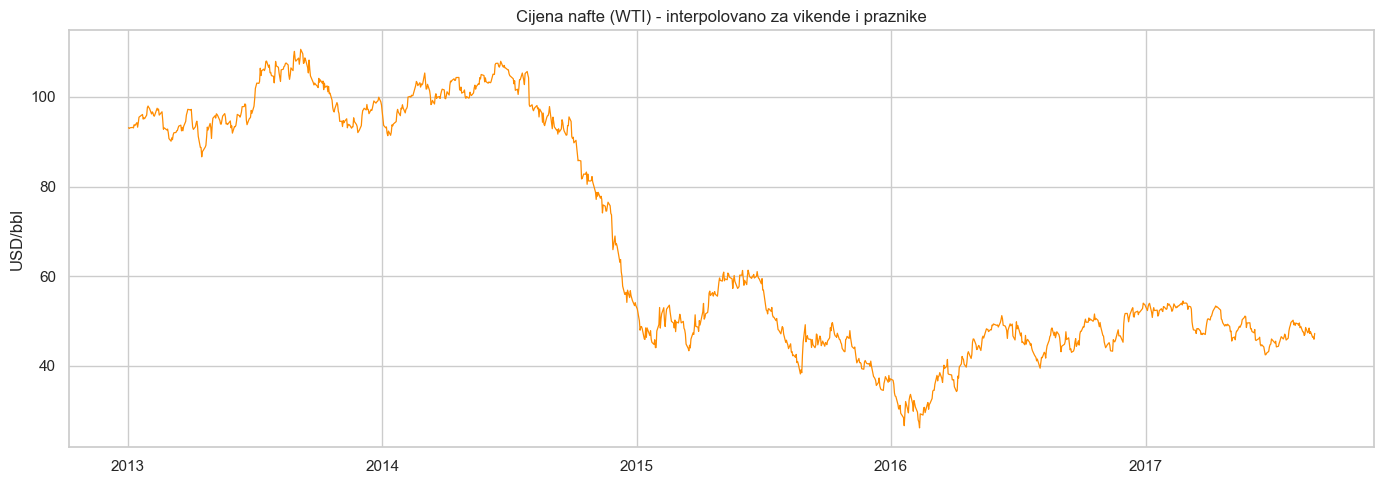

In [26]:
print(f'Missing values: {oil.dcoilwtico.isnull().sum()} ({oil.dcoilwtico.isnull().mean():.1%})')
print(f'Period: {oil.date.min().date()} do {oil.date.max().date()}')

# Vikendi i praznici nemaju cijenu - interpoliramo linearno
oil_full = oil.set_index('date').reindex(
    pd.date_range(oil.date.min(), oil.date.max())
).interpolate().reset_index()
oil_full.columns = ['date', 'dcoilwtico']

fig, ax = plt.subplots()
ax.plot(oil_full.date, oil_full.dcoilwtico, linewidth=0.9, color='darkorange')
ax.set_title('Cijena nafte (WTI) - interpolovano za vikende i praznike')
ax.set_ylabel('USD/bbl')
plt.tight_layout()
plt.show()

In [27]:
# Korelacija cijene nafte i ukupne prodaje
merged_oil = merged.merge(oil_full, on='date', how='left')
corr_oil = merged_oil['sales'].corr(merged_oil['dcoilwtico'])
print(f'Korelacija (sales vs cijena nafte): {corr_oil:.3f}')

Korelacija (sales vs cijena nafte): -0.631


## 6. holidays_events.csv

Vazno: `transferred=True` znaci da je taj dan premjesten i u stvari je normalan radni dan.
Stvarni praznik se nalazi u redu gdje je `type='Transfer'`.

In [28]:
holidays.head(10)

,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
5,2012-05-12,Holiday,Local,Puyo,Cantonizacion del Puyo,False
6,2012-06-23,Holiday,Local,Guaranda,Cantonizacion de Guaranda,False
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
8,2012-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
9,2012-06-25,Holiday,Local,Machala,Fundacion de Machala,False


In [29]:
print('Tipovi:', holidays['type'].value_counts().to_dict())
print('Locale:', holidays['locale'].value_counts().to_dict())
print('Transferred:', holidays['transferred'].value_counts().to_dict())

# Primjer transferovanog praznika
print('\nPrimjer - transferovani praznici:')
print(holidays[holidays['transferred'] == True].head(3)[['date','description','type','transferred']])
print('\nNjihovi stvarni datumi (type=Transfer):')
print(holidays[holidays['type'] == 'Transfer'].head(3)[['date','description','type']])

Tipovi: {'Holiday': 221, 'Event': 56, 'Additional': 51, 'Transfer': 12, 'Bridge': 5, 'Work Day': 5}
Locale: {'National': 174, 'Local': 152, 'Regional': 24}
Transferred: {False: 338, True: 12}

Primjer - transferovani praznici:
          date                 description     type  transferred
19  2012-10-09  Independencia de Guayaquil  Holiday         True
72  2013-10-09  Independencia de Guayaquil  Holiday         True
135 2014-10-09  Independencia de Guayaquil  Holiday         True

Njihovi stvarni datumi (type=Transfer):
          date                          description      type
20  2012-10-12  Traslado Independencia de Guayaquil  Transfer
73  2013-10-11  Traslado Independencia de Guayaquil  Transfer
136 2014-10-10  Traslado Independencia de Guayaquil  Transfer


In [30]:
# Ispravno: stvarni praznici su oni koji NISU transferred + oni gdje je type='Transfer'
real_holidays = holidays[
    (holidays['transferred'] == False) & (holidays['type'] != 'Bridge')
]

national_holidays = real_holidays[real_holidays['locale'] == 'National']['date'].unique()

daily2 = train.groupby('date')['sales'].sum().reset_index()
daily2['is_national_holiday'] = daily2['date'].isin(national_holidays)

effect = daily2.groupby('is_national_holiday')['sales'].mean()
print('Prosjecna dnevna prodaja (nacionalni praznici):')
print(f'  Obican dan:        {effect[False]:,.0f}')
print(f'  Nacionalni praznik:{effect[True]:,.0f}')
print(f'  Razlika:           {(effect[True]/effect[False]-1):+.1%}')

Prosjecna dnevna prodaja (nacionalni praznici):
  Obican dan:        628,086
  Nacionalni praznik:747,101
  Razlika:           +18.9%


## 7. Posebni eventi

### 7a. Efekat isplate plata (payday)

Plate u javnom sektoru isplacuju se 15. i zadnjeg dana u mjesecu.

In [31]:
daily3 = train.groupby('date')['sales'].sum().reset_index()
daily3['day'] = daily3['date'].dt.day
daily3['days_in_month'] = daily3['date'].dt.days_in_month
daily3['is_payday'] = (daily3['day'] == 15) | (daily3['day'] == daily3['days_in_month'])

payday_effect = daily3.groupby('is_payday')['sales'].mean()
print('Prosjecna dnevna prodaja:')
print(f'  Obican dan: {payday_effect[False]:,.0f}')
print(f'  Payday:     {payday_effect[True]:,.0f}')
print(f'  Razlika:    {(payday_effect[True]/payday_effect[False]-1):+.1%}')

Prosjecna dnevna prodaja:
  Obican dan: 636,963
  Payday:     645,966
  Razlika:    +1.4%


### 7b. Efekat zemljotresa (16. april 2016.)

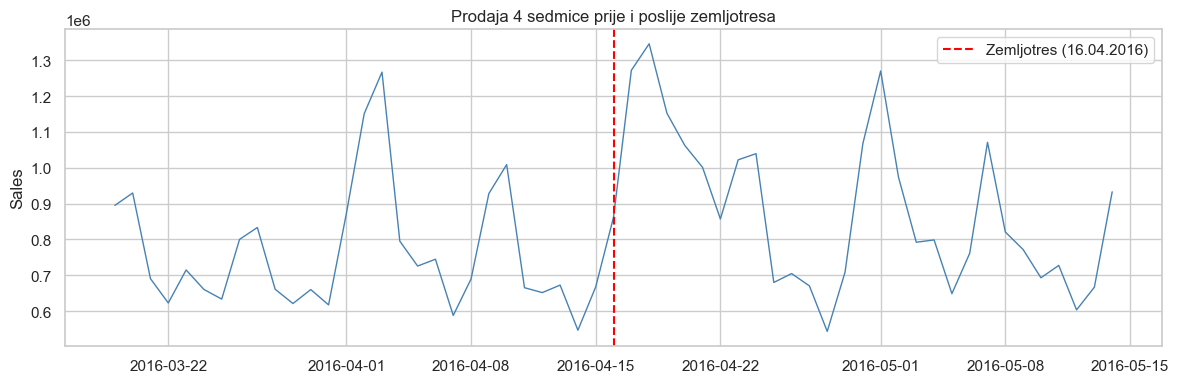

Prosjecna prodaja prije: 761,229
Prosjecna prodaja poslije: 880,676
Razlika: +15.7%


In [32]:
# Prodaja 4 sedmice prije i 4 sedmice poslije zemljotresa
window_start = EARTHQUAKE_DATE - pd.Timedelta(days=28)
window_end   = EARTHQUAKE_DATE + pd.Timedelta(days=28)

eq_window = daily3[(daily3['date'] >= window_start) & (daily3['date'] <= window_end)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(eq_window['date'], eq_window['sales'], color='steelblue', linewidth=1)
ax.axvline(EARTHQUAKE_DATE, color='red', linestyle='--', linewidth=1.5, label='Zemljotres (16.04.2016)')
ax.set_title('Prodaja 4 sedmice prije i poslije zemljotresa')
ax.set_ylabel('Sales')
ax.legend()
plt.tight_layout()
plt.show()

before = daily3[(daily3['date'] >= window_start) & (daily3['date'] < EARTHQUAKE_DATE)]['sales'].mean()
after  = daily3[(daily3['date'] > EARTHQUAKE_DATE) & (daily3['date'] <= window_end)]['sales'].mean()
print(f'Prosjecna prodaja prije: {before:,.0f}')
print(f'Prosjecna prodaja poslije: {after:,.0f}')
print(f'Razlika: {(after/before-1):+.1%}')

## 8. Zakljucak i plan za feature engineering

**Sta smo naucili:**
- train ima znacajan udio nula u sales - log1p transformacija za modeliranje
- cijena nafte ima missing values za vikende i praznike - linearna interpolacija
- jasna sedmicna sezonalnost (subota/nedjelja visi) i godisnja sezonalnost
- promocije povecavaju prodaju
- transferred praznici su normalni dani - koristiti samo type='Transfer' i transferred=False redove
- payday efekat (15. i zadnji u mjesecu) vidljiv u podacima
- zemljotres 16.04.2016. napravio anomaliju - treba ga oznaciti kao feature

**Merge plan za master dataset:**
- train + stores (left join na `store_nbr`)
- + transactions (left join na `date` + `store_nbr`)
- + oil interpolovano (left join na `date`)
- + holidays agregirano po datumu: national flag, local flag (po gradu)

**Features za modeliranje:**
- lag features: sales t-7, t-14, t-28 (t-1 nije dostupan za test)
- rolling mean: 7d, 14d, 28d
- kalendarske: dayofweek, month, weekofyear, is_weekend
- is_national_holiday, is_local_holiday (po gradu prodavnice)
- is_payday (15. i zadnji u mjesecu)
- days_after_earthquake (za period nakon 16.04.2016.)
- cijena nafte (interpolovana)
- store tip, cluster
- onpromotion